# Imports

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage import feature
from skimage.transform import resize
import math
import os
from scipy.io import savemat

# Functions

## perlin2D

In [10]:
"""
Inputs:
    res: [Wx, Wy] resolution in pixels of output perlin noise
    subsmpl: [sx, sy] samples between grid points
    ciel(res/sumsmpl)

Outputs:
    In: net noise
    
"""
def perlin2D(res, subsmpl):
    smpl = 1/subsmpl
    # print(smpl)

    # permutation lookup
    wl = 256 # wrap length
    
    p = np.random.permutation(np.arange(wl))

    # Avoid index wrapping:
    p = np.append(p,p)
    # print(f"p {p.shape}:\n{p}\n")

    # Gradients
    ngrads = 16
    g2 = np.array([np.cos(np.linspace(0, 2 * np.pi * (ngrads - 1)/ngrads, ngrads)), np.sin(np.linspace(0, 2* np.pi * (ngrads - 1)/ngrads, ngrads))])
    # print(f"g2 {g2.shape}:\n{g2}\n")
    # Fade or blending function
    fade = lambda t: 6 * np.power(t, 5) - 15 * np.power(t, 4) + 10 * np.power(t, 3) 

    # Compute perlin noise - vectorized implementation
    x,y = np.meshgrid(smpl[0] * np.arange(1, res[0]+1), smpl[1] * np.arange(1, res[1]+1))
    # print(f"x {x.shape}:\n{x}\n\ny {y.shape}:\n{y}")

    # Find the nearest grid point:
    x0 = np.floor(x)
    x1 = np.floor(x) + 1
    # print(f"x0 {x0.shape}: \n{x0}\n\nx1 {x1.shape}:\n{x1}")
    y0 = np.floor(y)
    y1 = np.floor(y) + 1
    # print(f"y0 {y0.shape}: \n{y0}\n\ny1 {y1.shape}:\n{y1}")

    # Distances (2D)
    tx0 = x - x0
    tx1 = x - x1
    # print(f"tx0 {tx0.shape}: \n{tx0}\n\ntx1 {tx1.shape}:\n{tx1}")
    ty0 = y - y0
    ty1 = y - y1
    # print(f"ty0 {ty0.shape}: \n{ty0}\n\nty1 {ty1.shape}:\n{ty1}")

    # # wrap grids at wrap length
    x0 = (np.mod(x0, wl)).astype(int)
    x1 = (np.mod(x1, wl)).astype(int)
    # print(f"x0 {x0.shape}: \n{x0}\n\nx1 {x1.shape}:\n{x1}")
    
    y0 = (np.mod(y0, wl)).astype(int)
    y1 = (np.mod(y1, wl)).astype(int)
    # print(f"y0 {y0.shape}: \n{y0}\n\ny1 {y1.shape}:\n{y1}")
    
    # # Calculate the 4 corner grad indicies
    gi00 = np.mod(p[x0 + p[y0]], ngrads)
    gi01 = np.mod(p[x0 + p[y1]], ngrads) 
    # print(f"gi00 {gi00.shape}: \n{gi00}\n\ngi01 {gi01.shape}:\n{gi01}")

    gi10 = np.mod(p[x1 + p[y0]], ngrads)
    gi11 = np.mod(p[x1 + p[y1]], ngrads)
    # print(f"gi10 {gi10.shape}{type(gi00)}: \n{gi10}\n\ngi11 {gi11.shape}:\n{gi11}")
    
    # Calculate the 4 corner grads
    g00 = np.stack((np.reshape(g2[0, gi00 - 1], np.shape(gi00)), np.reshape(g2[1, gi00 - 1], np.shape(gi00))), axis = 2)
    # print(f"g00 {g00.shape}: \n{g00}")

    g01 = np.stack((np.reshape(g2[0, gi01 - 1], np.shape(gi01)), np.reshape(g2[1, gi01 - 1], np.shape(gi01))), axis = 2)
    g10 = np.stack((np.reshape(g2[0, gi10 - 1], np.shape(gi10)), np.reshape(g2[1, gi10 - 1], np.shape(gi10))), axis = 2)
    g11 = np.stack((np.reshape(g2[0, gi11 - 1], np.shape(gi11)), np.reshape(g2[1, gi11 - 1], np.shape(gi11))), axis = 2)

    # Calculate the noise contrib from each of the 4 corners
    n00 = np.sum(g00 * np.stack((tx0, ty0), axis = 2), axis = 2)
    # print(f"n00 {n00.shape}:\n{n00}")
    n01 = np.sum(g01 * np.stack((tx0, ty1), axis = 2), axis = 2)
    # print(f"n01 {n01.shape}:\n{n01}")
    n10 = np.sum(g10 * np.stack((tx1, ty0), axis = 2), axis = 2)
    # print(f"n10 {n10.shape}:\n{n10}")
    n11 = np.sum(g11 * np.stack((tx1, ty1), axis = 2), axis = 2)
    # print(f"n11 {n11.shape}:\n{n11}")

    # Weights of each contribs
    w00 = fade(1 - tx0) * fade(1 - ty0)
    # print(f"w00 {w00.shape}:\n{w00}\n")
    w01 = fade(1 - tx0) * fade(ty0)
    # print(f"w01 {w01.shape}:\n{w01}\n")
    w10 = fade(tx0) * fade(1 - ty0)
    # print(f"w10 {w10.shape}:\n{w10}\n")
    w11 = fade(tx0) * fade(ty0)
    # print(f"w11 {w11.shape}:\n{w11}\n")

    return w00 * n00 + w01 * n01 + w10 * n10 + w11 * n11

## prop2D

In [18]:
def prop2D(Uin, Lxy, lambd, z, method):
    # print(f"lambd: {lambd}\n")
    Nx, Ny = Uin.shape
 
    Lx, Ly = Lxy
    
    fs_x = Nx/Lx
    fs_y = Ny/Ly

    fx = fs_x * np.arange(math.floor((-Nx+1)/2), math.ceil((Nx - 1)/ 2), 1) / Nx
    fy = (fs_y * np.arange(math.floor((-Ny+1)/2), math.ceil((Ny - 1)/ 2), 1) / Ny).T

    Fx, Fy = np.meshgrid(fx, fy)

    bp = np.sqrt(Fx ** 2 + Fy ** 2) < (1/lambd)

    if method == 'as':
        H = bp * np.exp(1j*2*np.pi * (z/lambd) * bp * (1-lambd**2 * (Fx ** 2 + Fy ** 2)))
    if method == 'fp':
        H = bp * np.exp(1j*2*np.pi*(z/lambd) * bp * 1-0.5*lambd**2 * (Fx ** 2 + Fy ** 2))
    
    A0 = np.fft.fft2(Uin, axes = (0,1))
    A0 = np.fft.fftshift(A0, axes = (0,1))


    Az = A0 * H
    Az = np.fft.ifftshift(Az, axes = (0,1))
    return np.fft.ifft2(Az, axes = (0,1))

    

## genPhaseMask

In [12]:
"""
Inputs:
    psf - Perlin noise
    lambd - wavelength in um
    pxSz - pixel size in um
    zMS - thickness in um
    method - 'as' or 'fp'

Outputs:
    phM - Phase map [0,2pi)
    Mm - Field at sensor plane
    MsA - Intensity or PSF at the sensor plane
"""

def genPhaseMask(psf, lambd, pxSz, thickness, numIters, method):
    zMS = thickness
    Mamp = np.sqrt(psf)
    Ms = Mamp

    netLenXY = np.multiply(psf.shape, pxSz)
    for i in range(numIters):
        Mm = prop2D(Ms, netLenXY, lambd, -zMS, method)
        Mm = Mm / abs(Mm)
        # print(f"1. Mm {Mm.shape}:\n{Mm}")
        # Handle nan
        Mm = np.nan_to_num(Mm)
        # print(f"2. Mm {Mm.shape}:\n{Mm}")
        phM = np.angle(Mm)
        # print(f"1. phM {phM.shape}:\n{phM}")
        phM[phM < 0] = 2 * np.pi + phM[phM < 0]
        # print(f"2. phM {phM.shape}:\n{phM}")
        if np.min(phM[:]) > np.pi:
            phM = phM - np.pi
            # print(f"3. phM {phM.shape}:\n{phM}")
        

        Ms = prop2D(Mm, netLenXY, lambd, zMS, 'as')
        MsA = np.abs(Ms) ** 2
        Ms = Mamp * Ms / np.sqrt(MsA)
    plt.subplot(1, 2, 1)        
    im = plt.imshow(phM, cmap = 'jet', aspect = 'equal', origin = 'lower')
    cbar = plt.colorbar(im)
    plt.title(f"Iter {i + 1}")
    plt.subplot(1, 2, 2)
    imgplot = plt.imshow(MsA)

    Mm = Mm.astype(np.float32)
    MsA = MsA.astype(np.float32)

    phM = np.angle(Mm)
    phM[phM < 0] = 2 * np.pi + phM[phM < 0]

    return phM, Mm, MsA


        
        
    

## quantPhaseMask

In [13]:
def quantPhaseMask(phM, lambd, dn, dh):
    c = lambd / (2 * np.pi * dn)
    phMh = phM * c
    phMhq = dh * np.floor(phMh/dh)
    phMq = phMhq / c
    im = plt.imshow(phMhq, cmap = 'jet', aspect = 'equal', origin = 'lower')
    print(f"Max height - \nContinuous {np.max(phMh[:]):.2f}um\nQuantized: {np.max(phMhq[:]):0.2f}um")
    return phMhq, phMq
    

# Main Functions

## Creating Perlin Noise

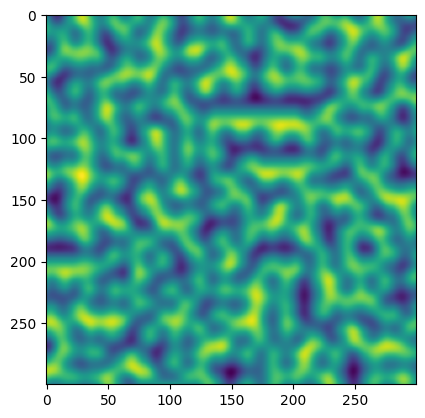

In [14]:
## Paths:
masksOutDir = './Masks/'

## Contour PSF Generation
pxSz = 2 # um pixel size of PSF and phase mask

## Create Perlin Contour Pattern
pName = 'Test'
minFeature = 12 #um Width of contour

## Fix Random Seed
# random.seed(a = 25, version = 2)
np.random.seed(10)

## Perlin noise generator:
pattern_size = np.array([300,300]) # Pixels
In = perlin2D(pattern_size, np.array([20,20]) )
plt.imshow(In)


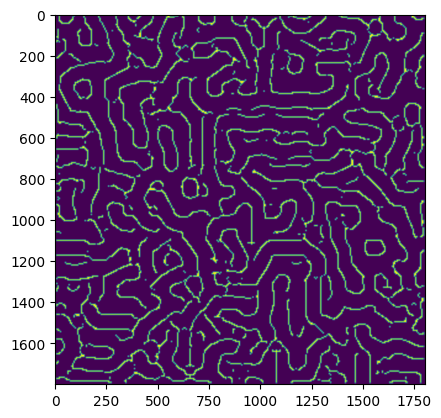

In [15]:
# imgplot = plt.imshow(In)

# Contour PSF creation
In = In - np.min(In)
In = np.divide(In, np.max(In))
# print(f"In {In.shape}:\n{In}\n")
Mp = feature.canny(In)
M = Mp.astype(float)

# Resize to get desired contour width
M = resize(M, (M[0].size * minFeature/pxSz, M[1].size * minFeature/pxSz))

imgplot = plt.imshow(M)



## Phase Mask Design

Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5
Nx: 1800
fs_x: 0.5


/var/folders/ll/fdhwcryx6vg4hnkwppj35t6c0000gn/T/ipykernel_17931/2578374828.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  Mm = Mm.astype(np.float32)


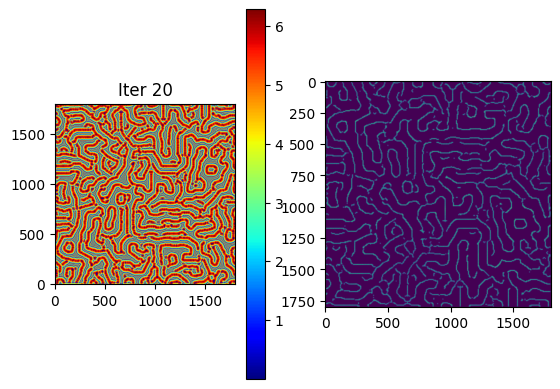

In [ ]:
# Camera thickness (mask-sensor distance)
T = 1869 # in um

# Generate the phase mask
zMS = T
lambd = 0.532 # in um
method = 'as' # as is angular spectrum
numIters = 20 # 20 - 100
netLenXY = np.multiply(M.shape, pxSz)# in um; Physical size of the mask
phMm, Mm, MsA = genPhaseMask(M, lambd, pxSz, zMS, numIters, method)


filename = (
    f"phMaskDes_{pName}_"
    f"{pxSz:0.2f}um_"
    f"{netLenXY[0]/1000:0.2f}mm_"
    f"{T}um_"
    f"lam{int(lambd*1000)}_"
    f"{method}.mat"
)

filepath = os.path.join(masksOutDir, filename)

savemat(
    filepath,
    {
        'Mm': Mm,
        'MsA': MsA,
        'phMm': phMm,
        'M': M,
        'pxSz': pxSz,
        'netLenXY': netLenXY,
        'zMS': zMS,
        'lambd': lambd
    },
    do_compression=False
)



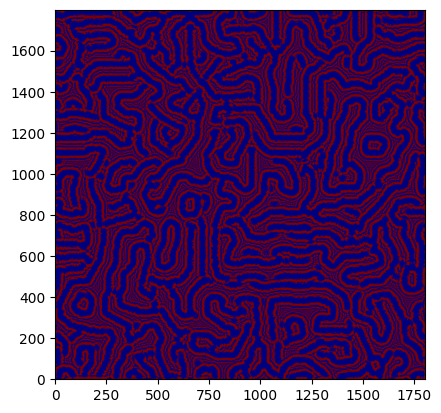

In [23]:
plt.imshow(phMm, cmap = 'jet', aspect = 'equal', origin = 'lower')

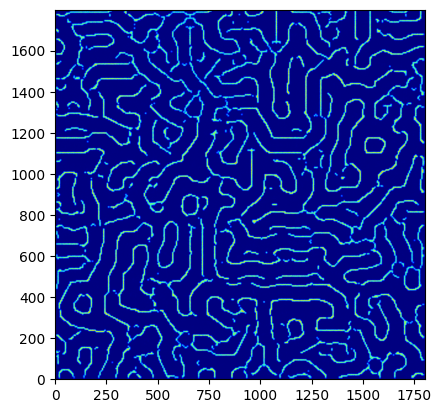

In [22]:
plt.imshow(MsA, cmap = 'jet', aspect = 'equal', origin = 'lower')

## Quantizing Phase Mask Height for Fabrication

Max height - 
Continuous 0.52um
Quantized: 0.40um
Nx: 1800
fs_x: 0.5


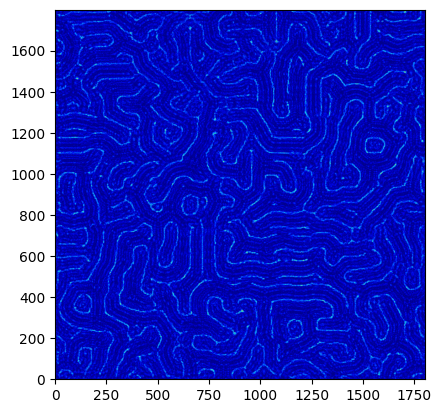

In [17]:
dn = 0.5103 # Refractive index difference of material with air
dh = 0.2 # um quantized height step size

netLenXY = np.multiply(phMm.shape, pxSz)

phMmHq, phMmq = quantPhaseMask(phMm, lambd, dn, dh)
Ms = prop2D(np.exp(1j*phMmq), netLenXY, lambd, zMS, 'as')
Ms = np.abs(Ms) ** 2
new = plt.imshow(Ms, cmap = 'jet', aspect = 'equal', origin = 'lower')